In [9]:
import os, sys
sys.path.insert(0, os.path.abspath('.')); 
sys.path.insert(0, os.path.abspath('..'))
sys.path.insert(0, os.path.abspath('../3dtesting')); 
sys.path.insert(0, os.path.abspath('../eos_mlp'))


import numpy as np 
import matplotlib.pyplot as plt 

import atmosphere_field as af, rt_forward as rf, invert, pretrain as pt, eos as eos_mod


In [10]:
# Then we want to predict the atmosphere from the retrieved atmosphere field.
nx, ny, nz = 128, 128, 56; 
dz = np.full(nz, 20.0e3); 
coords = af.grid_coords(nx, ny, nz);
params = af.load_params('/dat/milic/adora_pinn_develop/inverted_field.npz')


pred = pt.predict_grid(params, coords); 

In [11]:
pred.keys()

dict_keys(['T', 'P', 'vz', 'Bx', 'By', 'Bz', 'vturb'])

In [12]:
T = pred['T'].reshape(nx, ny, nz)
print(T.shape)

(128, 128, 56)


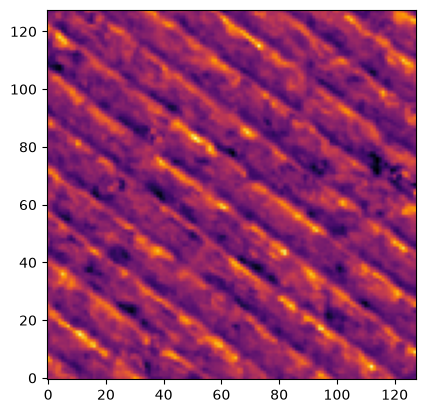

In [13]:
plt.imshow(T[:,:,10].T, origin='lower', cmap='inferno')

Text(0.5, 1.0, 'Vertical stratification at (64, 64)')

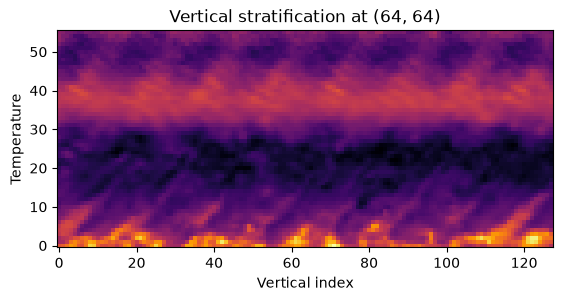

In [14]:
#What about the vertical stratification: 
plt.imshow(T[64, :, :].T, origin='lower', cmap='inferno')
plt.xlabel('Vertical index')
plt.ylabel('Temperature')
plt.title('Vertical stratification at (64, 64)')

In [15]:
z = np.arange(nz) * 20.0 - 100.0

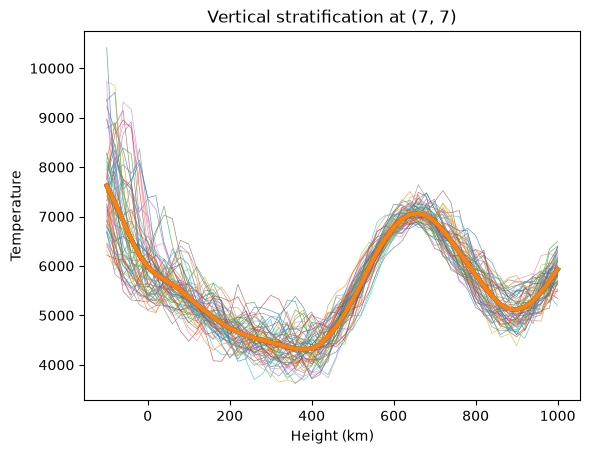

In [16]:
for i in range(0,8):
    for j in range(0,8):
        plt.plot(z, T[i*16, j*16, :],linewidth=0.5, alpha=0.7)
        plt.xlabel('Height (km)')
        plt.ylabel('Temperature')
        plt.title(f'Vertical stratification at ({i}, {j})')
    plt.plot(z, np.mean(T, axis=(0,1)), linewidth=3)